In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
import sys
from collections import Counter, defaultdict
from datetime import datetime

# ML libraries
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# Web requests
import requests

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
def download_hatexplain_data():
    """Download HateXplain main dataset from GitHub repository"""
    
    # Create data directory
    os.makedirs('data', exist_ok=True)
    
    # URL to the dataset
    dataset_url = 'https://raw.githubusercontent.com/hate-alert/HateXplain/master/Data/dataset.json'
    
    print("="*70)
    print("Downloading HateXplain Dataset...")
    print("="*70)
    
    # Download
    response = requests.get(dataset_url)
    response.raise_for_status()
    dataset = json.loads(response.text)
    
    print(f"Successfully downloaded: {len(dataset)} samples")
    
    # Save locally
    with open('data/hatexplain_raw.json', 'w') as f:
        json.dump(dataset, f, indent=2)
    
    print(f"Raw data saved to 'data/hatexplain_raw.json'")
    return dataset

# Download the data
raw_dataset = download_hatexplain_data()

# Show a sample
sample_key = list(raw_dataset.keys())[0]
sample = raw_dataset[sample_key]
print(f"\nSample data structure:")
print(f"  Post ID: {sample.get('post_id', 'N/A')}")
print(f"  Tokens: {sample.get('post_tokens', [])[:10]}...")
print(f"  Number of annotators: {len(sample.get('annotators', []))}")

Successfully downloaded: 20148 samples
Raw data saved to 'data/hatexplain_raw.json'

Sample data structure:
  Post ID: 1179055004553900032_twitter
  Tokens: ['i', 'dont', 'think', 'im', 'getting', 'my', 'baby', 'them', 'white', '9']...
  Number of annotators: 3


In [3]:
def convert_to_dataframe(raw_data):
    """Convert raw HateXplain data to pandas DataFrame"""
    
    print("\n" + "="*70)
    print("Processing Data...")
    print("="*70)
    
    # Label mapping
    label_mapping = {
        'hatespeech': 0,
        'normal': 1,
        'offensive': 2
    }
    
    processed_data = []
    
    for post_id, sample in raw_data.items():
        # Collect labels from all annotators
        labels = []
        targets = []
        
        for ann in sample['annotators']:
            label_str = ann['label'].lower()
            label_num = label_mapping.get(label_str, 1)
            labels.append(label_num)
            
            if 'target' in ann:
                targets.extend(ann['target'])
        
        # Majority vote for label
        label_counts = Counter(labels)
        majority_label = label_counts.most_common(1)[0][0]
        confidence = label_counts[majority_label] / len(labels)
        
        # Process rationales
        rationales = sample['rationales']
        rationale_agreement = []
        
        if rationales:
            for token_idx in range(len(sample['post_tokens'])):
                if token_idx < len(rationales[0]):
                    votes = sum(1 for rat in rationales 
                               if token_idx < len(rat) and rat[token_idx] == 1)
                    agreement = votes / len(rationales)
                    rationale_agreement.append(agreement)
                else:
                    rationale_agreement.append(0)
        else:
            rationale_agreement = [0] * len(sample['post_tokens'])
        
        # Create processed sample
        processed_data.append({
            'id': post_id,
            'tokens': sample['post_tokens'],
            'text': ' '.join(sample['post_tokens']),
            'label': majority_label,
            'label_name': ['hate', 'normal', 'offensive'][majority_label],
            'confidence': confidence,
            'targets': list(set(targets)) if targets else [],
            'rationale_agreement': rationale_agreement,
            'num_annotators': len(labels),
            'text_length': len(sample['post_tokens']),
            'has_rationales': sum(sum(rat) for rat in rationales) > 0 if rationales else False
        })
    
    df = pd.DataFrame(processed_data)
    print(f"Converted to DataFrame: {len(df)} samples")
    print(f"Columns: {list(df.columns)}")
    
    return df

# Convert to DataFrame
df = convert_to_dataframe(raw_dataset)

# Display basic info
print("\n" + "="*70)
print("Dataset Overview")
print("="*70)
print(f"Shape: {df.shape}")
print(f"\nFirst 3 rows:")
display(df[['text', 'label_name', 'confidence', 'text_length']].head(3))


Processing Data...
Converted to DataFrame: 20148 samples
Columns: ['id', 'tokens', 'text', 'label', 'label_name', 'confidence', 'targets', 'rationale_agreement', 'num_annotators', 'text_length', 'has_rationales']

Dataset Overview
Shape: (20148, 11)

First 3 rows:


,text,label_name,confidence,text_length
0,i dont think im getting my baby them white 9 h...,normal,1.000000,20
1,we cannot continue calling ourselves feminists...,normal,1.000000,42
2,nawt yall niggers ignoring me,normal,0.666667,5


In [4]:
print("="*70)
print("DATASET STATISTICS")
print("="*70)

print(f"\nTotal samples: {len(df)}")
print(f"Average text length: {df['text_length'].mean():.1f} tokens")
print(f"Samples with rationales: {df['has_rationales'].sum()}")

print("\nLabel Distribution:")
label_counts = df['label_name'].value_counts()
for label, count in label_counts.items():
    percentage = (count / len(df)) * 100
    print(f"  {label}: {count} ({percentage:.1f}%)")

print("\nConfidence Statistics:")
print(f"  Mean: {df['confidence'].mean():.3f}")
print(f"  Min: {df['confidence'].min():.3f}")
print(f"  Max: {df['confidence'].max():.3f}")

print("\nText Length Statistics:")
print(f"  Min: {df['text_length'].min()} tokens")
print(f"  Max: {df['text_length'].max()} tokens")
print(f"  Median: {df['text_length'].median():.0f} tokens")

DATASET STATISTICS

Total samples: 20148
Average text length: 23.6 tokens
Samples with rationales: 11413

Label Distribution:
  normal: 8153 (40.5%)
  hate: 6234 (30.9%)
  offensive: 5761 (28.6%)

Confidence Statistics:
  Mean: 0.814
  Min: 0.333
  Max: 1.000

Text Length Statistics:
  Min: 2 tokens
  Max: 165 tokens
  Median: 21 tokens


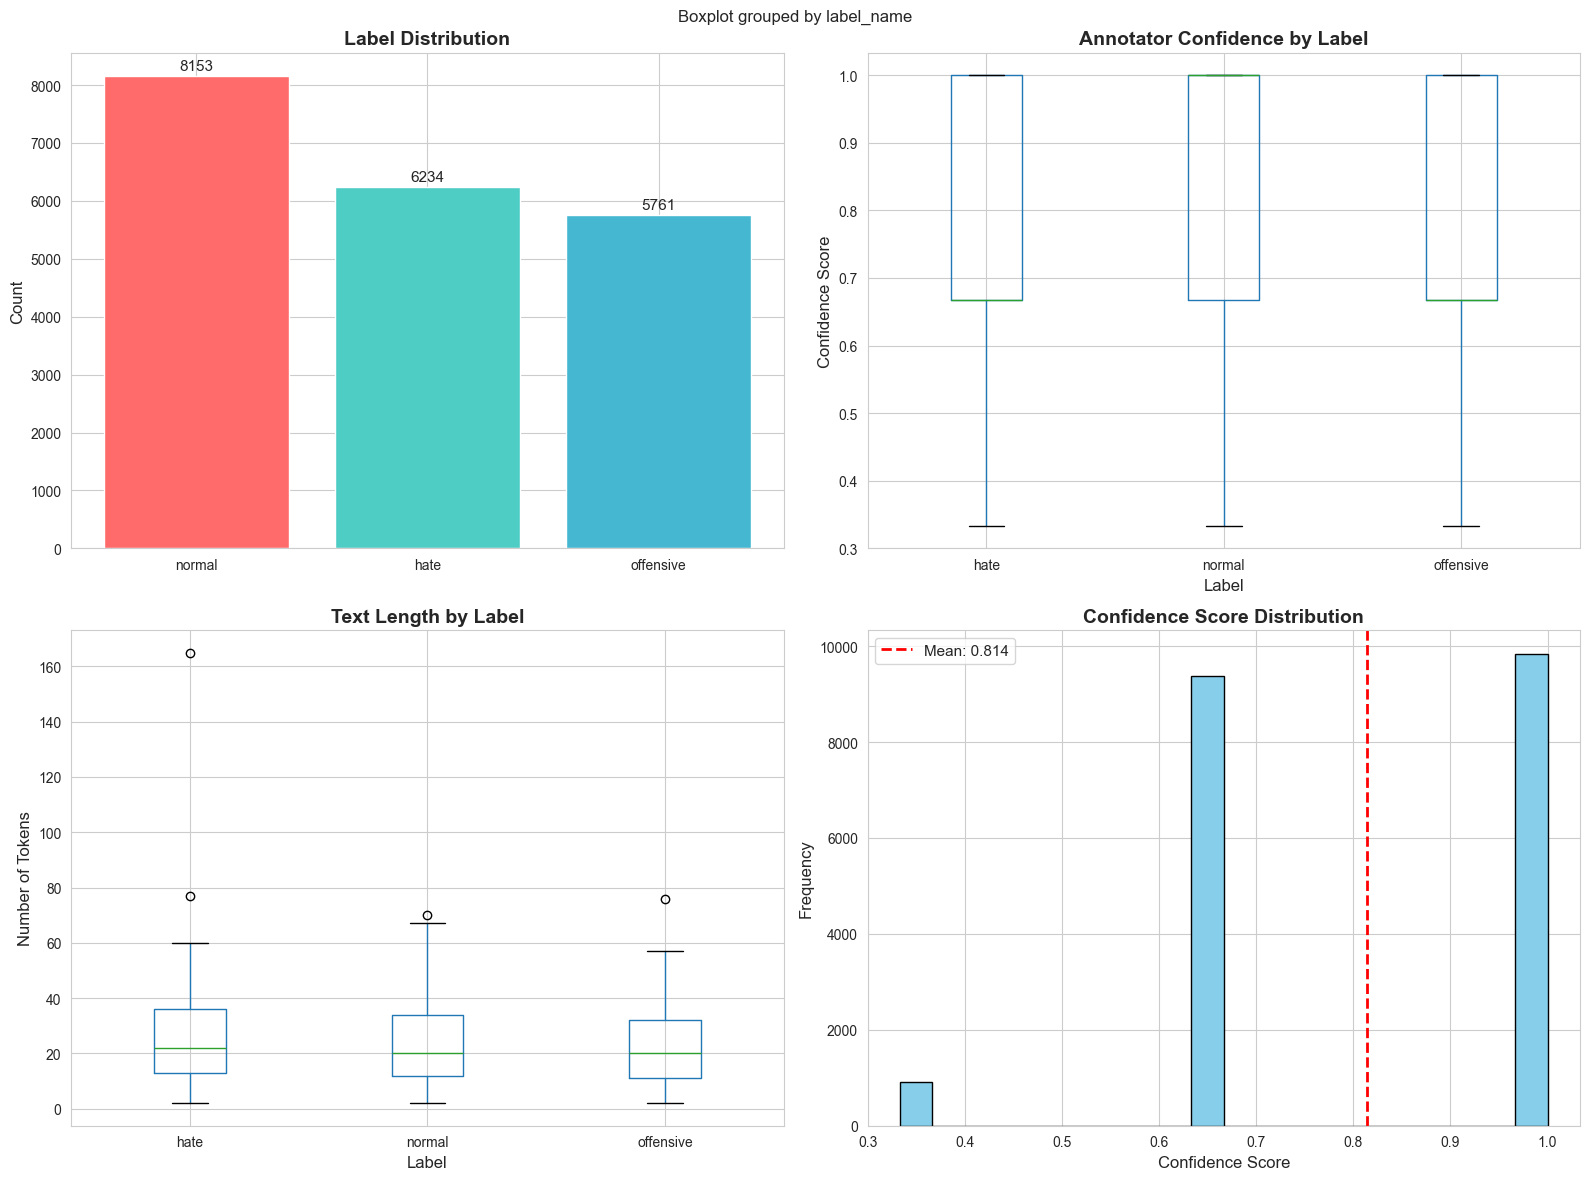

Visualizations generated successfully!


In [5]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Label distribution
label_counts = df['label_name'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0, 0].bar(label_counts.index, label_counts.values, color=colors)
axes[0, 0].set_title('Label Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=12)
for i, v in enumerate(label_counts.values):
    axes[0, 0].text(i, v + 50, str(v), ha='center', va='bottom', fontsize=11)

# 2. Confidence by label
df.boxplot(column='confidence', by='label_name', ax=axes[0, 1])
axes[0, 1].set_title('Annotator Confidence by Label', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Label', fontsize=12)
axes[0, 1].set_ylabel('Confidence Score', fontsize=12)
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

# 3. Text length by label
df.boxplot(column='text_length', by='label_name', ax=axes[1, 0])
axes[1, 0].set_title('Text Length by Label', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Label', fontsize=12)
axes[1, 0].set_ylabel('Number of Tokens', fontsize=12)
plt.sca(axes[1, 0])
plt.xticks(rotation=0)

# 4. Confidence distribution
axes[1, 1].hist(df['confidence'], bins=20, color='skyblue', edgecolor='black')
axes[1, 1].set_title('Confidence Score Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Confidence Score', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].axvline(df['confidence'].mean(), color='red', 
                   linestyle='--', linewidth=2, label=f'Mean: {df["confidence"].mean():.3f}')
axes[1, 1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Visualizations generated successfully!")

In [6]:
# Analyze target groups
target_counts = Counter()
target_by_label = defaultdict(Counter)

for _, row in df.iterrows():
    for target in row['targets']:
        target_counts[target] += 1
        target_by_label[row['label_name']][target] += 1

print("="*70)
print("TARGET GROUP ANALYSIS")
print("="*70)
print(f"Total unique target groups: {len(target_counts)}")
print(f"Posts with targets: {df[df['targets'].str.len() > 0].shape[0]}")

print("\nMost frequent target groups:")
for target, count in target_counts.most_common(10):
    print(f"  {target}: {count}")

print("\nTarget distribution by label:")
for label in ['hate', 'normal', 'offensive']:
    print(f"\n{label.upper()}:")
    for target, count in target_by_label[label].most_common(5):
        print(f"  {target}: {count}")

TARGET GROUP ANALYSIS
Total unique target groups: 25
Posts with targets: 20148

Most frequent target groups:
  None: 10772
  African: 4468
  Women: 3926
  Other: 3702
  Islam: 3201
  Homosexual: 2596
  Jewish: 2543
  Arab: 1784
  Refugee: 1701
  Caucasian: 1698

Target distribution by label:

HATE:
  African: 2630
  Islam: 1648
  Jewish: 1631
  Women: 1106
  Arab: 1035

NORMAL:
  None: 7355
  Women: 1088
  Other: 1030
  African: 744
  Homosexual: 680

OFFENSIVE:
  None: 2476
  Other: 1750
  Women: 1732
  African: 1094
  Homosexual: 994


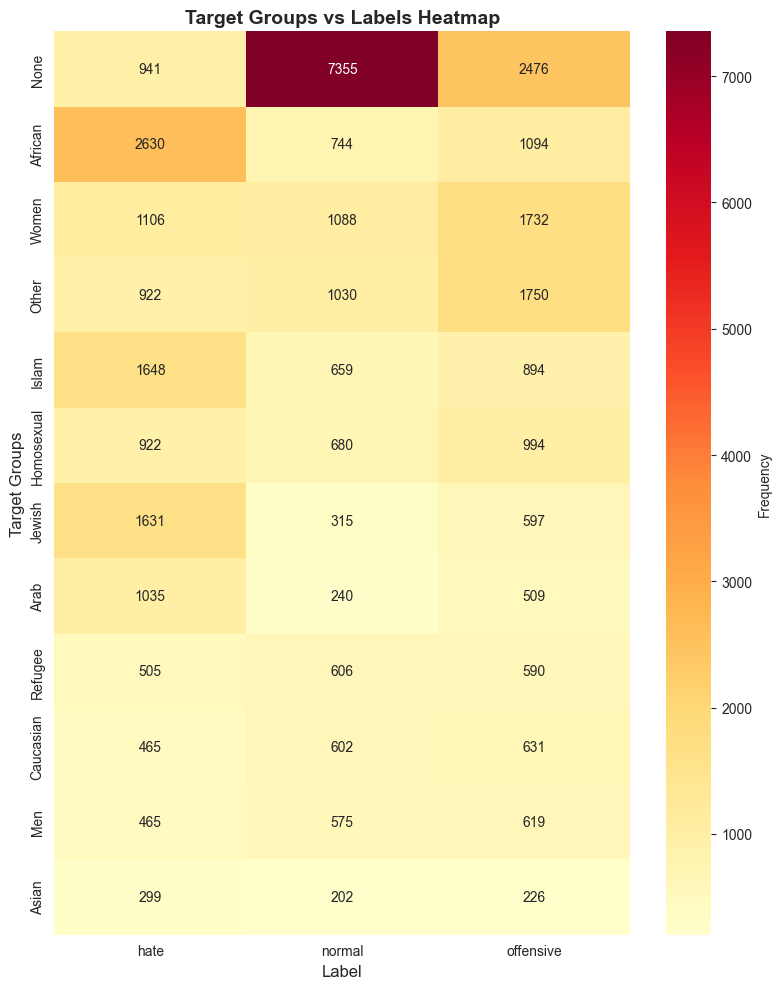

Target group heatmap generated!


In [7]:
# Create target group heatmap
top_targets = list(dict(target_counts.most_common(12)).keys())
labels = ['hate', 'normal', 'offensive']

target_matrix = []
for target in top_targets:
    row = [target_by_label[label][target] for label in labels]
    target_matrix.append(row)

plt.figure(figsize=(8, 10))
sns.heatmap(target_matrix, 
            xticklabels=labels,
            yticklabels=top_targets,
            annot=True, 
            fmt='d', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Frequency'})

plt.title('Target Groups vs Labels Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Label', fontsize=12)
plt.ylabel('Target Groups', fontsize=12)
plt.tight_layout()
plt.show()

print("Target group heatmap generated!")

In [8]:
# Show sample texts from each category
print("="*70)
print("SAMPLE TEXTS FROM EACH CATEGORY")
print("="*70)

for label in ['hate', 'normal', 'offensive']:
    print(f"\n{label.upper()} Examples:")
    samples = df[df['label_name'] == label].sample(min(3, len(df[df['label_name'] == label])))
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        print(f"\n{i}. {row['text'][:100]}...")
        print(f"   Confidence: {row['confidence']:.2f} | Length: {row['text_length']} tokens")
        

SAMPLE TEXTS FROM EACH CATEGORY

HATE Examples:

1. cantwell is actually talking to federal agents and nehlen has a spic wife so what you are saying doe...
   Confidence: 0.67 | Length: 40 tokens

2. <user> oh boy you are a retard but can be chill you remind me of the kid we used to fuck in the lock...
   Confidence: 0.67 | Length: 27 tokens

3. u are retarded if u think trump doesnt pay taxes he has paid more in taxes in his life than most of ...
   Confidence: 0.33 | Length: 34 tokens

NORMAL Examples:

1. how ghetto do you have to be to steal from your friends...
   Confidence: 1.00 | Length: 12 tokens

2. while middle america was alternating between struggling along economically and finding cheap distrac...
   Confidence: 0.67 | Length: 45 tokens

3. <user> wignats secretly jealous of the jews because they have an ethnostate and they do not lmao...
   Confidence: 1.00 | Length: 17 tokens

OFFENSIVE Examples:

1. my being a highly educated exemplar equipped with an exemplary mastery

In [9]:
# Configuration class
class Config:
    """Configuration for model training"""
    
    # Model selection
    MODEL_NAME = 'prajjwal1/bert-tiny'  # changed from distilbert-base-uncased ( 2 hour with 3 epoch, 4 with 5, hopefully better speed
    #prajjwal1/bert-tiny was fast but a little too inaccurate - albert-base-v2 was 5 hours
    
    # Training parameters
    NUM_LABELS = 3
    MAX_LENGTH = 64 # Changed for better speed, might need to increase to better accuracy
    BATCH_SIZE = 16 # Tried increasing to 64, brought down accuracy
    LEARNING_RATE = 2e-5
    NUM_EPOCHS = 5  # Increased to 5 for hopefully better accuracy
    WEIGHT_DECAY = 0.01
    WARMUP_STEPS = 500 # Tried lowering to 100, brought down accuracy
    
    # Data split
    TEST_SIZE = 0.2
    VAL_SIZE = 0.1
    RANDOM_SEED = 42
    
    # Paths
    OUTPUT_DIR = './models/hatexplain_detector'
    LOGS_DIR = './logs'
    RESULTS_DIR = './results'
    
    # Training options
    USE_GPU = torch.cuda.is_available()
    FP16 = torch.cuda.is_available()
    EARLY_STOPPING_PATIENCE = 3
    SAVE_TOTAL_LIMIT = 2
    USE_CLASS_WEIGHTS = True

# Create directories
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
os.makedirs(Config.LOGS_DIR, exist_ok=True)
os.makedirs(Config.RESULTS_DIR, exist_ok=True)

print("="*70)
print("MODEL CONFIGURATION")
print("="*70)
print(f"Model: {Config.MODEL_NAME}")
print(f"Epochs: {Config.NUM_EPOCHS}")
print(f"Batch Size: {Config.BATCH_SIZE}")
print(f"Learning Rate: {Config.LEARNING_RATE}")
print(f"Max Length: {Config.MAX_LENGTH}")
print(f"Device: {'GPU' if Config.USE_GPU else 'CPU'}")
print(f"Mixed Precision (FP16): {Config.FP16}")

MODEL CONFIGURATION
Model: prajjwal1/bert-tiny
Epochs: 5
Batch Size: 16
Learning Rate: 2e-05
Max Length: 64
Device: CPU
Mixed Precision (FP16): False


In [10]:
def prepare_dataset(df, config):
    """Prepare dataset for training"""
    
    print("\n" + "="*70)
    print("PREPARING DATASET")
    print("="*70)
    
    # Filter low confidence samples (optional)
    print(f"Initial samples: {len(df)}")
    df_filtered = df[df['confidence'] >= 0.5].copy()
    print(f"After confidence filtering (>=0.5): {len(df_filtered)}")
    
    # Ensure label is integer
    df_filtered['label'] = df_filtered['label'].astype(int)
    
    # Split into train and test
    train_df, test_df = train_test_split(
        df_filtered[['text', 'label']],
        test_size=config.TEST_SIZE,
        random_state=config.RANDOM_SEED,
        stratify=df_filtered['label']
    )
    
    # Split train into train and validation
    train_df, val_df = train_test_split(
        train_df,
        test_size=config.VAL_SIZE,
        random_state=config.RANDOM_SEED,
        stratify=train_df['label']
    )
    
    print(f"\nDataset splits:")
    print(f"  Training: {len(train_df)}")
    print(f"  Validation: {len(val_df)}")
    print(f"  Test: {len(test_df)}")
    
    # Convert to HuggingFace Dataset
    train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
    val_dataset = Dataset.from_pandas(val_df, preserve_index=False)
    test_dataset = Dataset.from_pandas(test_df, preserve_index=False)
    
    dataset_dict = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset,
        'test': test_dataset
    })
    
    # Print label distribution
    print("\nLabel distribution in splits:")
    for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        label_dist = split_df['label'].value_counts().sort_index()
        print(f"\n{split_name}:")
        for label, count in label_dist.items():
            label_name = ['hate', 'normal', 'offensive'][label]
            print(f"  {label_name}: {count} ({count/len(split_df)*100:.1f}%)")
    
    return dataset_dict, train_df, val_df, test_df

# Prepare dataset
dataset_dict, train_df, val_df, test_df = prepare_dataset(df, Config)


PREPARING DATASET
Initial samples: 20148
After confidence filtering (>=0.5): 19229

Dataset splits:
  Training: 13844
  Validation: 1539
  Test: 3846

Label distribution in splits:

Train:
  hate: 4273 (30.9%)
  normal: 5626 (40.6%)
  offensive: 3945 (28.5%)

Val:
  hate: 475 (30.9%)
  normal: 625 (40.6%)
  offensive: 439 (28.5%)

Test:
  hate: 1187 (30.9%)
  normal: 1563 (40.6%)
  offensive: 1096 (28.5%)


In [11]:
def setup_model_and_tokenizer(config):
    """Initialize model and tokenizer"""
    
    print("\n" + "="*70)
    print(f"LOADING MODEL: {config.MODEL_NAME}")
    print("="*70)
    
    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
    
    # Load model
    model = AutoModelForSequenceClassification.from_pretrained(
        config.MODEL_NAME,
        num_labels=config.NUM_LABELS,
        problem_type="single_label_classification"
    )
    
    print(f"Model loaded: {config.MODEL_NAME}")
    print(f"Number of parameters: {model.num_parameters():,}")
    print(f"Device: {'GPU' if config.USE_GPU else 'CPU'}")
    
    return model, tokenizer

# Setup model and tokenizer
model, tokenizer = setup_model_and_tokenizer(Config)


LOADING MODEL: prajjwal1/bert-tiny


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: prajjwal1/bert-tiny
Number of parameters: 4,386,307
Device: CPU


In [12]:
def tokenize_function(examples):
    """Tokenize text data"""
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=Config.MAX_LENGTH,
        return_tensors=None
    )

print("Tokenizing datasets...")
tokenized_datasets = dataset_dict.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']
)
print("Tokenization complete!")

Tokenizing datasets...


Map:   0%|          | 0/13844 [00:00<?, ? examples/s]

Map:   0%|          | 0/1539 [00:00<?, ? examples/s]

Map:   0%|          | 0/3846 [00:00<?, ? examples/s]

Tokenization complete!


In [13]:

def compute_metrics(eval_pred):
    """Compute metrics for evaluation"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

# Training arguments
training_args = TrainingArguments(
    output_dir=Config.OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=Config.LEARNING_RATE,
    per_device_train_batch_size=Config.BATCH_SIZE,
    per_device_eval_batch_size=Config.BATCH_SIZE,
    num_train_epochs=Config.NUM_EPOCHS,
    weight_decay=Config.WEIGHT_DECAY,
    warmup_steps=Config.WARMUP_STEPS,
    logging_dir=Config.LOGS_DIR,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=Config.SAVE_TOTAL_LIMIT,
    fp16=Config.FP16,
    report_to="none",
    seed=Config.RANDOM_SEED
)

print("Training arguments configured!")

Training arguments configured!


In [14]:
# Data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=Config.EARLY_STOPPING_PATIENCE)]
)

print("Trainer initialized!")

Trainer initialized!


In [15]:
print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)
print(f"Training on {len(tokenized_datasets['train'])} samples")
print(f"Validating on {len(tokenized_datasets['validation'])} samples")
# This may take a while!!

# Train
train_result = trainer.train()

print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)
print(f"Training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"Training loss: {train_result.metrics['train_loss']:.4f}")

# Save model
trainer.save_model(Config.OUTPUT_DIR)
tokenizer.save_pretrained(Config.OUTPUT_DIR)
print(f"\nModel saved to: {Config.OUTPUT_DIR}")


STARTING TRAINING
Training on 13844 samples
Validating on 1539 samples


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.931300,0.911540,0.558804,0.451635,0.479951
2,0.889300,0.849272,0.625081,0.581825,0.597621
3,0.839800,0.829757,0.628980,0.590224,0.605634
4,0.766000,0.823637,0.635478,0.603079,0.617321
5,0.804700,0.817691,0.643275,0.611336,0.624978



TRAINING COMPLETE!
Training time: 516.35 seconds
Training loss: 0.8654

Model saved to: ./models/hatexplain_detector


In [16]:
print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)

# Get predictions
predictions_output = trainer.predict(tokenized_datasets['test'])
predictions = np.argmax(predictions_output.predictions, axis=1)
labels = predictions_output.label_ids

# Label names
label_names = ['hate', 'normal', 'offensive']

# Classification report
print("\nClassification Report:")
print(classification_report(labels, predictions, target_names=label_names))

# Calculate metrics
accuracy = accuracy_score(labels, predictions)
f1_macro = f1_score(labels, predictions, average='macro')
f1_weighted = f1_score(labels, predictions, average='weighted')

print("\nOverall Metrics:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  F1 (macro): {f1_macro:.4f}")
print(f"  F1 (weighted): {f1_weighted:.4f}")


MODEL EVALUATION



Classification Report:
              precision    recall  f1-score   support

        hate       0.74      0.76      0.75      1187
      normal       0.63      0.84      0.72      1563
   offensive       0.59      0.30      0.40      1096

    accuracy                           0.66      3846
   macro avg       0.65      0.63      0.62      3846
weighted avg       0.65      0.66      0.64      3846


Overall Metrics:
  Accuracy: 0.6609
  F1 (macro): 0.6234
  F1 (weighted): 0.6383


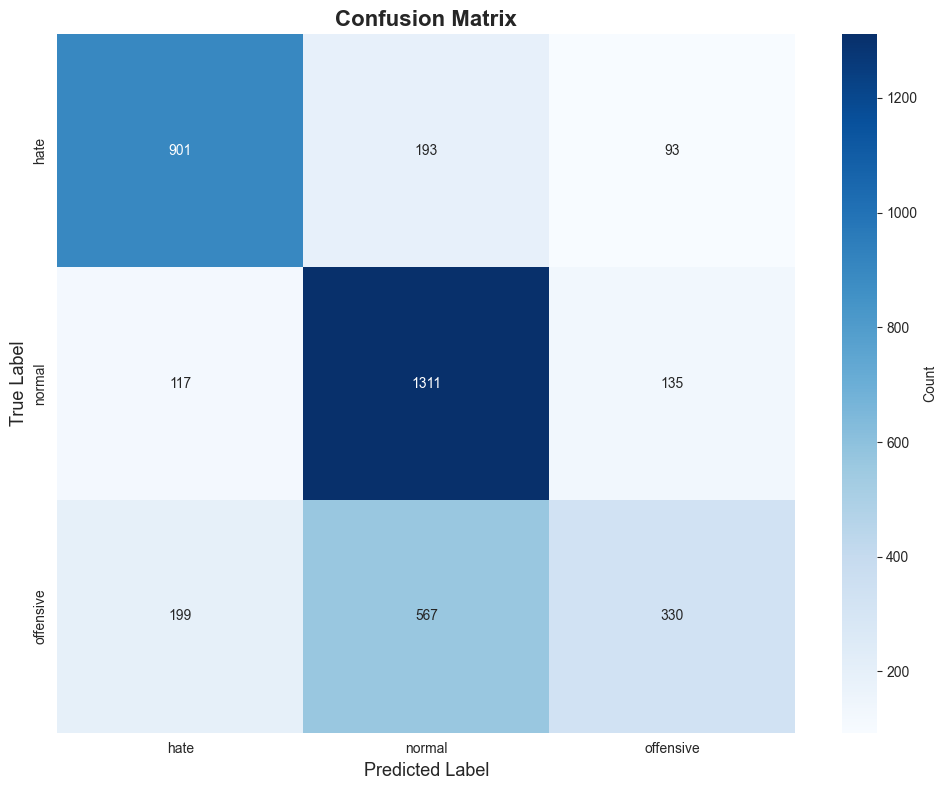

Confusion matrix saved to: ./results/confusion_matrix.png


In [17]:
# Confusion matrix
cm = confusion_matrix(labels, predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=13)
plt.xlabel('Predicted Label', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Confusion matrix saved to: {Config.RESULTS_DIR}/confusion_matrix.png")

In [18]:
# Save detailed results
results = {
    'accuracy': float(accuracy),
    'f1_macro': float(f1_macro),
    'f1_weighted': float(f1_weighted),
    'classification_report': classification_report(labels, predictions, target_names=label_names, output_dict=True),
    'confusion_matrix': cm.tolist(),
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

results_path = os.path.join(Config.RESULTS_DIR, 'evaluation_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Detailed results saved to: {results_path}")

Detailed results saved to: ./results\evaluation_results.json


In [19]:
def predict_hate_speech(text, model_path=None):
    """
    Predict hate speech for new text
    
    Args:
        text: Input text or list of texts
        model_path: Path to saved model
    
    Returns:
        Dictionary with predictions and probabilities
    """
    if model_path is None:
        model_path = Config.OUTPUT_DIR
    
    # Load model and tokenizer
    tokenizer_pred = AutoTokenizer.from_pretrained(model_path)
    model_pred = AutoModelForSequenceClassification.from_pretrained(model_path)
    model_pred.eval()
    
    # Handle single text or list
    if isinstance(text, str):
        texts = [text]
        single_input = True
    else:
        texts = text
        single_input = False
    
    # Tokenize
    inputs = tokenizer_pred(
        texts,
        padding=True,
        truncation=True,
        max_length=Config.MAX_LENGTH,
        return_tensors='pt'
    )
    
    # Predict
    with torch.no_grad():
        outputs = model_pred(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1)
        predictions = torch.argmax(probabilities, dim=-1)
    
    # Format results
    label_names = ['hate', 'normal', 'offensive']
    results = []
    
    for i, text_input in enumerate(texts):
        pred_label = predictions[i].item()
        probs = probabilities[i].tolist()
        
        results.append({
            'text': text_input,
            'predicted_label': label_names[pred_label],
            'predicted_label_id': pred_label,
            'probabilities': {
                label_names[j]: probs[j] for j in range(len(label_names))
            },
            'confidence': max(probs)
        })
    
    return results[0] if single_input else results

print("Inference function defined!")

Inference function defined!


In [20]:
print("="*70)
print("SAMPLE PREDICTIONS")
print("="*70)

# Test samples, can change according to tests
test_samples = [
    "I love everyone regardless of their background!",
    "You people are disgusting and should leave",
    "This is so stupid, what a waste of time",
    "Have a great day everyone!",
    "Those immigrants are ruining our country"
]

predictions = predict_hate_speech(test_samples)

for pred in predictions:
    print(f"\nText: {pred['text']}")
    print(f"Prediction: {pred['predicted_label'].upper()} (confidence: {pred['confidence']:.3f})")
    print(f"Probabilities:")
    for label, prob in pred['probabilities'].items():
        print(f"  {label}: {prob:.3f}")
    print("-" * 70)

SAMPLE PREDICTIONS

Text: I love everyone regardless of their background!
Prediction: NORMAL (confidence: 0.750)
Probabilities:
  hate: 0.039
  normal: 0.750
  offensive: 0.211
----------------------------------------------------------------------

Text: You people are disgusting and should leave
Prediction: OFFENSIVE (confidence: 0.451)
Probabilities:
  hate: 0.106
  normal: 0.443
  offensive: 0.451
----------------------------------------------------------------------

Text: This is so stupid, what a waste of time
Prediction: NORMAL (confidence: 0.604)
Probabilities:
  hate: 0.050
  normal: 0.604
  offensive: 0.346
----------------------------------------------------------------------

Text: Have a great day everyone!
Prediction: NORMAL (confidence: 0.678)
Probabilities:
  hate: 0.051
  normal: 0.678
  offensive: 0.271
----------------------------------------------------------------------

Text: Those immigrants are ruining our country
Prediction: NORMAL (confidence: 0.552)
Probabili

In [21]:
# For live demo purposes, replace the test
custom_text = "I hate yall, hope u die"

result = predict_hate_speech(custom_text)

print("\n" + "="*70)
print("YOUR TEXT PREDICTION")
print("="*70)
print(f"\nText: {result['text']}")
print(f"\nPrediction: {result['predicted_label'].upper()}")
print(f"Confidence: {result['confidence']:.1%}")
print(f"\nProbability breakdown:")
for label, prob in result['probabilities'].items():
    bar_length = int(prob * 50)
    bar = '█' * bar_length
    print(f"  {label:10s} [{bar:50s}] {prob:.1%}")


YOUR TEXT PREDICTION

Text: I hate yall, hope u die

Prediction: NORMAL
Confidence: 42.9%

Probability breakdown:
  hate       [███████                                           ] 15.0%
  normal     [█████████████████████                             ] 42.9%
  offensive  [█████████████████████                             ] 42.0%
